In [19]:
from __future__ import annotations
import os, random, math, time
from dataclasses import dataclass
from typing import List, Tuple
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt

@dataclass
class CFG:
    infra_dir: str = "infra_2"      
    noninfra_dir: str = "noninfra_2"
    img_size: int = 224 # Because resnet18 model expects 224x224 images cuz its trained on imagenet dataset that has 224x224 images
    batch_size: int = 16 # Samples per step
    max_epochs: int = 5 # max epochs
    lr: float = 3e-4 # learning rate for Adam Optimiser
    weight_decay: float = 1e-4 # L2 regularization to reduce overfitting
    seed: int = 42 # Control Randomness
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    val_frac: float = 0.2 # 20% for Validation
    test_frac: float = 0.2 # 20% for Testing
    num_workers: int = 2 # Parallel CPU workers for input/output transforms
    freeze_backbone: bool = False

cfg = CFG()

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)
print("Device:", cfg.device)


Device: cpu


In [20]:
# Dataset setup for Infrastructure vs Non-Infrastructure classification

from PIL import Image
import os
from torch.utils.data import Dataset
from torchvision import transforms

# ImageNet normalization constants
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def list_images(folder: str):
    files = []
    for root, _, filenames in os.walk(folder):
        for fn in filenames:
            if os.path.splitext(fn)[1].lower() in IMG_EXTS:
                files.append(os.path.join(root, fn))
    return sorted(files)

class InfraBinaryDataset(Dataset):

    def __init__(self, infra_files, noninfra_files, transform=None):
        self.files = infra_files + noninfra_files
        self.labels = [1] * len(infra_files) + [0] * len(noninfra_files) #Infrastructure =1,Non-Infrastructure =0
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        y = self.labels[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(y, dtype=torch.float32), path

# Training transforms with augmentation
t_train = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)), # Resize images to 224x224
    transforms.RandomHorizontalFlip(), # Randomly flip images to left --> right 
    transforms.RandomVerticalFlip(), # Randomly flip images to top --> bottom
    transforms.RandomRotation(degrees=20), # Randomly rotating images by +20 deg or -20deg
    transforms.ToTensor(), # converting images to pytorch tensor
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), # Applying imagenet mean and std to match Resnet18
])

# Evaluation transforms - For Validation and Testing
t_eval = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Loading file paths
infra_files = list_images(cfg.infra_dir)
noninfra_files = list_images(cfg.noninfra_dir)

print(f"Infrastructure images: {len(infra_files)}")
print(f"Non-Infrastructure images: {len(noninfra_files)}")

assert len(infra_files) > 0 and len(noninfra_files) > 0, \
    " "


Infrastructure images: 600
Non-Infrastructure images: 700


In [21]:
# Labels for stratification
labels = np.array([1]*len(infra_files) + [0]*len(noninfra_files)) # Infrastructure = 1 Non Infrastructure = 0
all_files = infra_files + noninfra_files # Combined all image paths to a single list
indices = np.arange(len(all_files))

# Stratify indices by label
def stratified_split(indices, labels, val_frac, test_frac, seed=42):
    rng = np.random.RandomState(seed)
    idx_pos = indices[labels == 1]
    idx_neg = indices[labels == 0]
    rng.shuffle(idx_pos); rng.shuffle(idx_neg)

    def split_one(arr):
        n = len(arr)
        n_test = int(round(test_frac*n))
        n_val  = int(round(val_frac*n))
        test = arr[:n_test]
        val  = arr[n_test:n_test+n_val]
        train = arr[n_test+n_val:]
        return train, val, test
    # shuffeling infrastructure and non infrastructure images independantly
    tr_p, va_p, te_p = split_one(idx_pos)
    tr_n, va_n, te_n = split_one(idx_neg)
    # Splitting test, validation and other 60% to train
    train_idx = np.concatenate([tr_p, tr_n])
    val_idx   = np.concatenate([va_p, va_n])
    test_idx  = np.concatenate([te_p, te_n])

    rng.shuffle(train_idx); rng.shuffle(val_idx); rng.shuffle(test_idx)
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(indices, labels, cfg.val_frac, cfg.test_frac, cfg.seed)

def subset(files, idxs):
    return [files[i] for i in idxs]

train_ds = InfraBinaryDataset(subset(all_files, train_idx), [], transform=t_train)

train_labels = labels[train_idx].tolist()
train_ds.files = [all_files[i] for i in train_idx]
train_ds.labels = train_labels

val_ds = InfraBinaryDataset([], [], transform=t_eval)
val_ds.files = [all_files[i] for i in val_idx]
val_ds.labels = labels[val_idx].tolist()

test_ds = InfraBinaryDataset([], [], transform=t_eval)
test_ds.files = [all_files[i] for i in test_idx]
test_ds.labels = labels[test_idx].tolist()

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

print(f"Train/Val/Test sizes: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")


Train/Val/Test sizes: 780 / 260 / 260


In [22]:
# CNN baseline Model With Resnet18 
class CNNBaseline(nn.Module):
    def __init__(self, freeze_backbone=False):
        super().__init__()
        # Loading Resnet18 with imagenet weights
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        # Stopping updating pretrained weight during training
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()  
        self.head = nn.Linear(in_feats, 1)  
    # Passing image through Resnet 18 to extract features
    def forward(self, x):
        feats = self.backbone(x) 
        logit = self.head(feats).squeeze(1) 
        return logit

cnn_baseline = CNNBaseline(freeze_backbone=cfg.freeze_backbone).to(cfg.device)


In [23]:
def make_grid_adjacency(H: int, W: int, self_loops=True):
    N = H*W # Total number of nodes 
    edges = []
    def node(r, c): return r*W + c
    for r in range(H):
        for c in range(W):
            u = node(r, c)
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                r2, c2 = r+dr, c+dc
                if 0 <= r2 < H and 0 <= c2 < W:
                    v = node(r2, c2)
                    edges.append((u, v))
    A = torch.zeros((N, N), dtype=torch.float32)
    for u, v in edges:
        A[u, v] = 1.0
    if self_loops:
        A += torch.eye(N)
    deg = A.sum(dim=1)
    D_inv_sqrt = torch.diag(torch.pow(deg, -0.5).clamp(min=1e-6))
    A_hat = D_inv_sqrt @ A @ D_inv_sqrt
    return A_hat  

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0, activation=True):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU(inplace=True) if activation else nn.Identity()

    def forward(self, X, A_hat):  
        X = self.lin(X)           
        X = torch.einsum("ij,bjd->bid", A_hat, X)
        X = self.act(X)
        X = self.dropout(X)
        return X

class CNN_GNN(nn.Module):
    def __init__(self, freeze_backbone=False, g_hidden=256, g_out=128, dropout=0.1):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for p in backbone.parameters():
                p.requires_grad = False
        # Keep up to layer4
        self.stem = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4
        )
        self.feat_dim = 512  # resnet18 layer4 
        self.pool = nn.AdaptiveAvgPool2d((7,7))

        # Graph layers
        self.g1 = GCNLayer(self.feat_dim, g_hidden, dropout=dropout, activation=True)
        self.g2 = GCNLayer(g_hidden, g_out, dropout=dropout, activation=True)

        self.head = nn.Linear(g_out, 1)  

        H = W = 7
        A_hat = make_grid_adjacency(H, W, self_loops=True)  
        self.register_buffer("A_hat", A_hat)

        # For Grad-CAM access
        self._last_conv_out = None
        # CNN Feature Extraction
    def forward(self, x):
        fmap = self.stem(x)               
        fmap = self.pool(fmap)            
        self._last_conv_out = fmap       
        B, C, H, W = fmap.shape
        X = fmap.flatten(2).transpose(1, 2)   
        # Graph massage Passing
        X = self.g1(X, self.A_hat)            
        X = self.g2(X, self.A_hat)            
        X = X.mean(dim=1)                      
        logit = self.head(X).squeeze(1)       
        return logit
# Instantiating hybrid model
hybrid = CNN_GNN(freeze_backbone=cfg.freeze_backbone).to(cfg.device)


In [24]:
# Model Evaluation
def bce_logits_loss(logits, y):
    
    return F.binary_cross_entropy_with_logits(logits, y)

@torch.no_grad()
def run_eval(model, loader, device):
    model.eval()
    all_probs, all_preds, all_targets = [], [], []
    total_loss = 0.0
    for x, y, _ in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = bce_logits_loss(logits, y)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        total_loss += loss.item() * x.size(0)
        all_probs.append(probs.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    acc = accuracy_score(all_targets, all_preds)
    f1  = f1_score(all_targets, all_preds, zero_division=0)
    try:
        auc = roc_auc_score(all_targets, all_probs)
    except Exception:
        auc = float("nan")
    aupr = average_precision_score(all_targets, all_probs)
    avg_loss = total_loss / len(loader.dataset)
    return {
        "loss": avg_loss, "acc": acc, "f1": f1, "auc": auc, "aupr": aupr,
        "probs": all_probs, "preds": all_preds, "targets": all_targets
    }

def train_model(model, train_loader, val_loader, device, lr, weight_decay, max_epochs=15, model_name="model"):
    opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    best_val_f1 = -1.0
    best_state = None
    history = {"epoch": [], "tr_loss": [], "va_loss": [], "va_acc": [], "va_f1": [], "va_auc": [], "va_aupr": []}

    for epoch in range(1, max_epochs+1):
        model.train()
        tr_loss_total = 0.0
        for x, y, _ in train_loader:
            x = x.to(device); y = y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = bce_logits_loss(logits, y)
            loss.backward()
            opt.step()
            tr_loss_total += loss.item()*x.size(0)

        # Eval
        val = run_eval(model, val_loader, device)
        tr_loss = tr_loss_total/len(train_loader.dataset)
        history["epoch"].append(epoch)
        history["tr_loss"].append(tr_loss)
        history["va_loss"].append(val["loss"])
        history["va_acc"].append(val["acc"])
        history["va_f1"].append(val["f1"])
        history["va_auc"].append(val["auc"])
        history["va_aupr"].append(val["aupr"])

        print(f"[{model_name}] Epoch {epoch:02d} | "
              f"train loss {tr_loss:.4f} | val loss {val['loss']:.4f} | "
              f"val acc {val['acc']:.3f} f1 {val['f1']:.3f} auc {val['auc']:.3f} aupr {val['aupr']:.3f}")

        if val["f1"] > best_val_f1:
            best_val_f1 = val["f1"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


In [25]:
# Training both models (CNN baseline and Hybrid CNN+GNN)

import os
import time
import torch
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds, batch_size=cfg.batch_size, shuffle=True,
    num_workers=0, pin_memory=False
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.batch_size, shuffle=False,
    num_workers=0, pin_memory=False
)
test_loader = DataLoader(
    test_ds, batch_size=cfg.batch_size, shuffle=False,
    num_workers=0, pin_memory=False
)

# Instantiating models 
cnn_baseline = CNNBaseline(freeze_backbone=cfg.freeze_backbone).to(cfg.device)
hybrid = CNN_GNN(freeze_backbone=cfg.freeze_backbone).to(cfg.device)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Device:", cfg.device)
print(f"CNN trainable params   : {count_trainable_params(cnn_baseline):,}")
print(f"Hybrid trainable params: {count_trainable_params(hybrid):,}")

x_test, y_test, _ = next(iter(train_loader))
x_test = x_test.to(cfg.device); y_test = y_test.to(cfg.device)
with torch.no_grad():
    _ = cnn_baseline(x_test)
    _ = hybrid(x_test)
print("Sanity forward pass OK.")

# Training CNN baseline model
print("\nTraining CNN baseline...")
t0 = time.time()
hist_cnn = train_model(
    cnn_baseline, train_loader, val_loader,
    cfg.device, cfg.lr, cfg.weight_decay,
    max_epochs=cfg.max_epochs, model_name="CNN"
)
t1 = time.time()
print(f"CNN training finished in {t1 - t0:.1f}s.")

# Training Hybrid model
print("\nTraining Hybrid CNN+GNN...")
t0 = time.time()
hist_hybrid = train_model(
    hybrid, train_loader, val_loader,
    cfg.device, cfg.lr, cfg.weight_decay,
    max_epochs=cfg.max_epochs, model_name="Hybrid"
)
t1 = time.time()
print(f"Hybrid training finished in {t1 - t0:.1f}s.")

# Saving weights
os.makedirs("checkpoints", exist_ok=True)
torch.save(cnn_baseline.state_dict(), "checkpoints/cnn_baseline_best.pt")
torch.save(hybrid.state_dict(), "checkpoints/hybrid_cnn_gnn_best.pt")
print("Saved checkpoints to ./checkpoints/")

# Quick validation summary
val_cnn = run_eval(cnn_baseline, val_loader, cfg.device)
val_hyb = run_eval(hybrid, val_loader, cfg.device)

def _summ(name, r):
    print(f"{name} | val acc {r['acc']:.3f}  f1 {r['f1']:.3f}  auc {r['auc']:.3f}  aupr {r['aupr']:.3f}")

print("\nValidation quick summary:")
_summ("CNN   ", val_cnn)
_summ("Hybrid", val_hyb)
# 11177025 - 11340865 = 163840 from GCN head

Device: cpu
CNN trainable params   : 11,177,025
Hybrid trainable params: 11,340,865
Sanity forward pass OK.

Training CNN baseline...
[CNN] Epoch 01 | train loss 0.2791 | val loss 0.4002 | val acc 0.885 f1 0.888 auc 0.989 aupr 0.987
[CNN] Epoch 02 | train loss 0.1473 | val loss 0.0812 | val acc 0.973 f1 0.971 auc 0.997 aupr 0.997
[CNN] Epoch 03 | train loss 0.0877 | val loss 0.0861 | val acc 0.969 f1 0.967 auc 0.993 aupr 0.989
[CNN] Epoch 04 | train loss 0.0572 | val loss 0.1208 | val acc 0.965 f1 0.962 auc 0.994 aupr 0.993
[CNN] Epoch 05 | train loss 0.1298 | val loss 0.1315 | val acc 0.962 f1 0.959 auc 0.994 aupr 0.993
CNN training finished in 700.6s.

Training Hybrid CNN+GNN...
[Hybrid] Epoch 01 | train loss 0.2779 | val loss 0.1672 | val acc 0.946 f1 0.944 auc 0.984 aupr 0.982
[Hybrid] Epoch 02 | train loss 0.1679 | val loss 0.1819 | val acc 0.954 f1 0.950 auc 0.985 aupr 0.981
[Hybrid] Epoch 03 | train loss 0.1301 | val loss 0.0901 | val acc 0.965 f1 0.964 auc 0.995 aupr 0.996
[Hyb


=== CNN Test Results ===
Loss: 0.1184
Acc : 0.9692
F1  : 0.9675
ROC-AUC: 0.9929
PR-AUC : 0.9872

=== Hybrid Test Results ===
Loss: 0.0590
Acc : 0.9808
F1  : 0.9791
ROC-AUC: 0.9968
PR-AUC : 0.9957


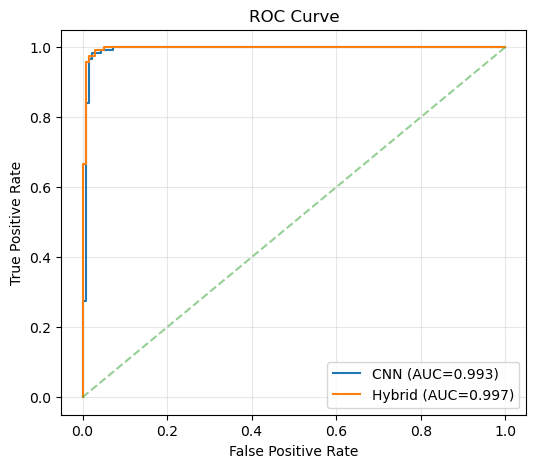

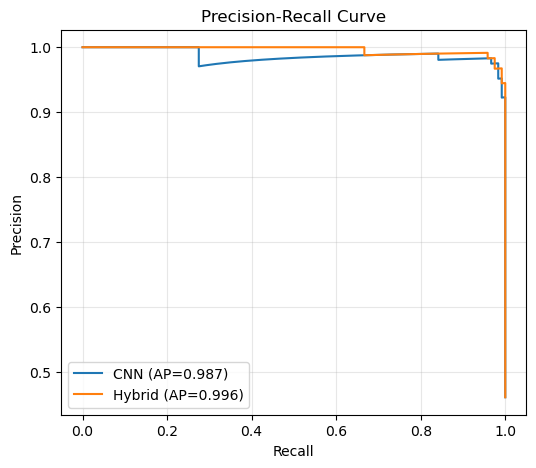

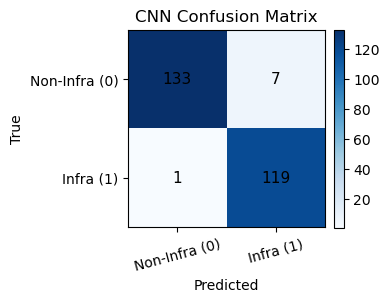

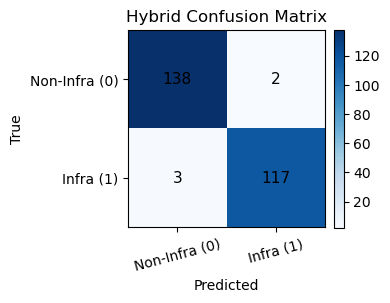

In [26]:
# Evaluating on test set
res_cnn = run_eval(cnn_baseline, test_loader, cfg.device)
res_hyb = run_eval(hybrid, test_loader, cfg.device)

def print_summary(name, res):
    print(f"\n=== {name} Test Results ===")
    print(f"Loss: {res['loss']:.4f}")
    print(f"Acc : {res['acc']:.4f}")
    print(f"F1  : {res['f1']:.4f}")
    print(f"ROC-AUC: {res['auc']:.4f}")
    print(f"PR-AUC : {res['aupr']:.4f}")

print_summary("CNN", res_cnn)
print_summary("Hybrid", res_hyb)

# ROC curves
fpr_cnn, tpr_cnn, _ = roc_curve(res_cnn["targets"], res_cnn["probs"])
fpr_h, tpr_h, _ = roc_curve(res_hyb["targets"], res_hyb["probs"])
plt.figure(figsize=(6,5))
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC={res_cnn['auc']:.3f})")
plt.plot(fpr_h, tpr_h, label=f"Hybrid (AUC={res_hyb['auc']:.3f})")
plt.plot([0,1],[0,1],'--',alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# Precision-Recall curves
prec_cnn, rec_cnn, _ = precision_recall_curve(res_cnn["targets"], res_cnn["probs"])
prec_h, rec_h, _ = precision_recall_curve(res_hyb["targets"], res_hyb["probs"])
plt.figure(figsize=(6,5))
plt.plot(rec_cnn, prec_cnn, label=f"CNN (AP={res_cnn['aupr']:.3f})")
plt.plot(rec_h, prec_h, label=f"Hybrid (AP={res_hyb['aupr']:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# Confusion matrices (heatmaps)
def plot_confusion(name, res):
    cm = confusion_matrix(res["targets"], res["preds"])
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Non-Infra (0)","Infra (1)"], rotation=15)
    ax.set_yticklabels(["Non-Infra (0)","Infra (1)"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center", color="black", fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

plot_confusion("CNN", res_cnn)
plot_confusion("Hybrid", res_hyb)


In [27]:
# Evaluate best checkpoints on TEST
res_cnn = run_eval(cnn_baseline, test_loader, cfg.device)
res_hyb = run_eval(hybrid, test_loader, cfg.device)

def summ(name, r):
    print(f"{name:6} | test acc {r['acc']:.3f}  f1 {r['f1']:.3f}  auc {r['auc']:.3f}  aupr {r['aupr']:.3f}")
summ("CNN", res_cnn); summ("Hybrid", res_hyb)

# Bootstrap 95% CI for F1 and AUC
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

def bootstrap_ci(y, p, metric_fn, n=2000, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    stats = []
    for _ in range(n):
        b = rng.choice(idx, size=len(idx), replace=True)
        yy, pp = y[b], p[b]
        if metric_fn is f1_score:
            preds = (pp >= 0.5).astype(np.float32)
            stats.append(metric_fn(yy, preds, zero_division=0))
        else:
            stats.append(metric_fn(yy, pp))
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return np.mean(stats), lo, hi

for name, r in [("CNN", res_cnn), ("Hybrid", res_hyb)]:
    mf, l_f, h_f = bootstrap_ci(r["targets"], r["probs"], f1_score)
    ma, l_a, h_a = bootstrap_ci(r["targets"], r["probs"], roc_auc_score)
    print(f"{name} | F1 mean {mf:.3f} [95% {l_f:.3f},{h_f:.3f}] | AUC mean {ma:.3f} [95% {l_a:.3f},{h_a:.3f}]")

# McNemars test on test predictions (same images, two models)
from sklearn.metrics import confusion_matrix
y_true = res_cnn["targets"].astype(int)
preds_cnn = (res_cnn["probs"] >= 0.5).astype(int)
preds_hyb = (res_hyb["probs"] >= 0.5).astype(int)
cnn_wrong = preds_cnn != y_true
hyb_wrong = preds_hyb != y_true
b = np.logical_and(cnn_wrong, ~hyb_wrong).sum()  # CNN wrong, Hybrid right
c = np.logical_and(~cnn_wrong, hyb_wrong).sum()  # CNN right, Hybrid wrong
chi2 = (abs(b - c) - 1)**2 / (b + c + 1e-9)
print(f"McNemar: b={b}, c={c}, chi2={chi2:.3f} (~>3.84 => p<0.05)")

# Calibration -> reliability curve + Brier score
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
for name, r in [("CNN", res_cnn), ("Hybrid", res_hyb)]:
    prob_true, prob_pred = calibration_curve(r["targets"], r["probs"], n_bins=10, strategy="uniform")
    bs = brier_score_loss(r["targets"], r["probs"])
    print(f"{name} | Brier {bs:.4f} | Reliability bins (true vs pred):")
    print(np.vstack([prob_true, prob_pred]).T)


CNN    | test acc 0.969  f1 0.967  auc 0.993  aupr 0.987
Hybrid | test acc 0.981  f1 0.979  auc 0.997  aupr 0.996
CNN | F1 mean 0.967 [95% 0.942,0.988] | AUC mean 0.993 [95% 0.980,1.000]
Hybrid | F1 mean 0.979 [95% 0.958,0.996] | AUC mean 0.997 [95% 0.990,1.000]
McNemar: b=6, c=3, chi2=0.444 (~>3.84 => p<0.05)
CNN | Brier 0.0220 | Reliability bins (true vs pred):
[[0.         0.00992277]
 [0.         0.13230205]
 [0.         0.26948181]
 [0.33333333 0.33130926]
 [0.         0.44001603]
 [0.         0.59554249]
 [0.4        0.64408115]
 [0.5        0.84848088]
 [0.98305085 0.99416784]]
Hybrid | Brier 0.0160 | Reliability bins (true vs pred):
[[0.00746269 0.00333995]
 [0.         0.11961411]
 [0.         0.20034079]
 [1.         0.38317987]
 [0.         0.46483165]
 [1.         0.58734453]
 [1.         0.63484395]
 [0.66666667 0.84302872]
 [0.99122807 0.99156013]]


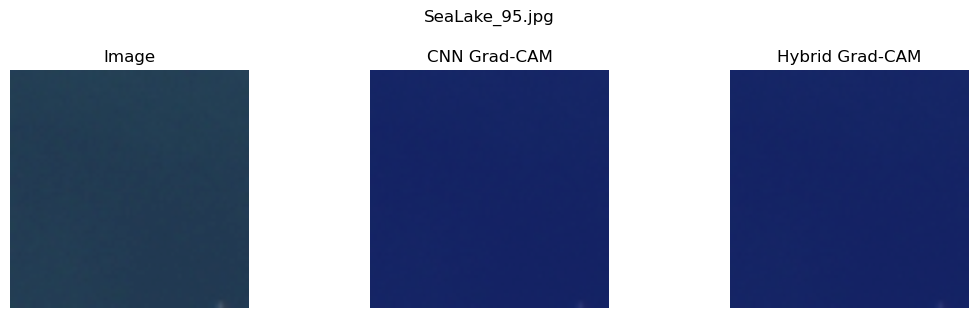

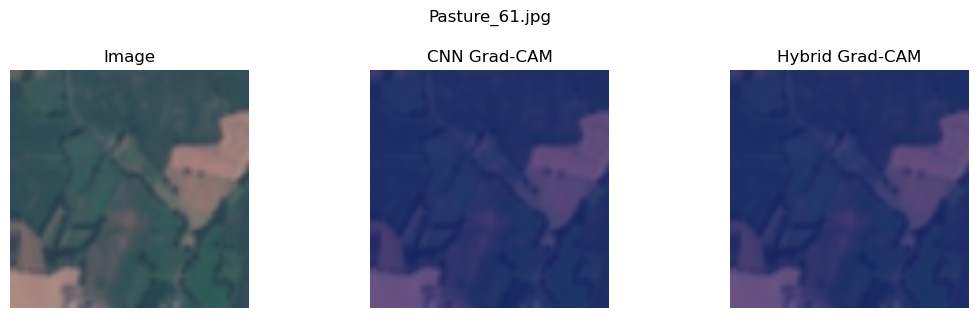

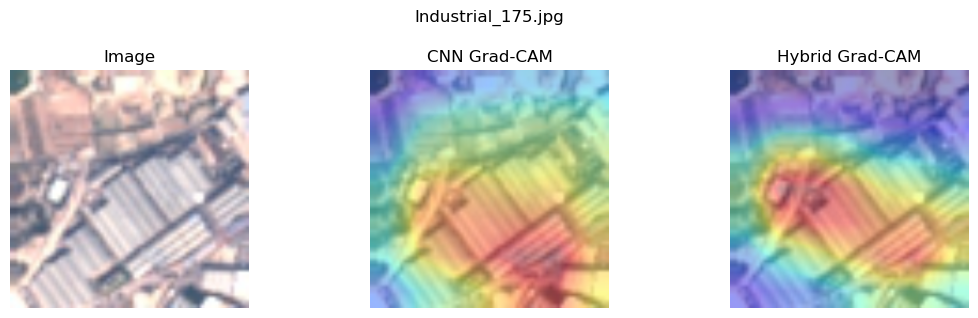

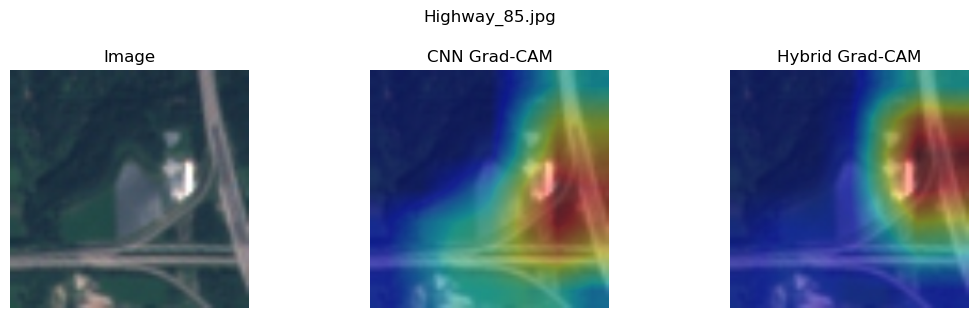

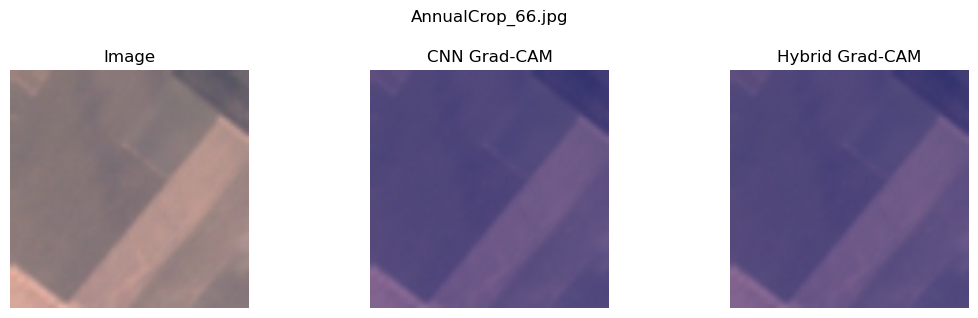

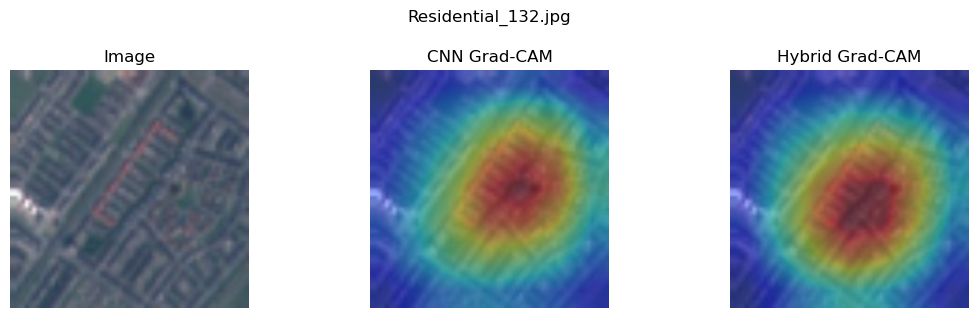

In [28]:
# Grad-CAM visualizations (CNN vs Hybrid)

import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from typing import Tuple

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Grad-CAM helper

class GradCAM:
    
    def __init__(self, model: torch.nn.Module, target_module: torch.nn.Module):
        self.model = model
        self.target_module = target_module
        self.activations = None
        self.gradients = None
        self.fwd_hook = target_module.register_forward_hook(self._save_activation)
        self.bwd_hook = target_module.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def clear(self):
        self.activations = None
        self.gradients = None

    def __del__(self):
        try:
            self.fwd_hook.remove()
            self.bwd_hook.remove()
        except:
            pass

    @torch.no_grad()
    def forward_only(self, x: torch.Tensor):
        self.model.eval()
        return self.model(x)

    def cam(self, x: torch.Tensor, use_sigmoid_target: bool = True) -> torch.Tensor:
        
        self.model.eval()
        self.clear()
        x = x.requires_grad_(True)

        # Forward
        logits = self.model(x)
        if use_sigmoid_target:
            score = torch.sigmoid(logits).sum()
        else:
            score = logits.sum()

        # Backward
        self.model.zero_grad(set_to_none=True)
        score.backward(retain_graph=True)

        A = self.activations            
        G = self.gradients             
        weights = G.mean(dim=(2, 3), keepdim=True)        
        cam = (weights * A).sum(dim=1, keepdim=True)      
        cam = F.relu(cam)

        # Normalize each sample to [0,1]
        B, _, H, W = cam.shape
        cam = cam.view(B, -1)
        cam = cam - cam.min(dim=1, keepdim=True).values
        cam = cam / (cam.max(dim=1, keepdim=True).values.clamp_min(1e-6))
        cam = cam.view(B, 1, H, W).detach()
        return cam

# Overlay utility

def overlay_cam_on_image(img_tensor: torch.Tensor, cam: torch.Tensor, alpha: float = 0.4) -> Tuple[np.ndarray, np.ndarray]:
    
    # Unnormalize
    img = img_tensor.cpu()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = (img * std) + mean
    img = img.clamp(0, 1)

    H, W = img.shape[1], img.shape[2]
    cam_up = F.interpolate(cam, size=(H, W), mode="bilinear", align_corners=False).cpu()[0, 0].numpy()

    base = img.permute(1, 2, 0).numpy()
    heat = plt.cm.jet(cam_up)[..., :3] 
    overlay = (1 - alpha) * base + alpha * heat
    overlay = np.clip(overlay, 0, 1)
    return base, overlay


# Build hooks on last conv
# CNN-only - last conv block is backbone.layer4
cnn_cam = GradCAM(cnn_baseline, cnn_baseline.backbone.layer4)

# Hybrid - stem ends with layer4 
hyb_cam = GradCAM(hybrid, hybrid.stem[-1])

# Visualising test samples
save_dir = "gradcam_figs"
os.makedirs(save_dir, exist_ok=True)

examples = 6   # Image Count
shown = 0

for x, y, paths in test_loader:
    bsz = x.size(0)
    for i in range(bsz):
        img_b = x[i:i+1].to(cfg.device)     

        # CNN Grad-CAM
        _ = cnn_cam.forward_only(img_b)     
        cam1 = cnn_cam.cam(img_b)          

        # Hybrid Grad-CAM
        _ = hyb_cam.forward_only(img_b)
        cam2 = hyb_cam.cam(img_b)

        # Overlays
        base, ov1 = overlay_cam_on_image(x[i], cam1)
        _,    ov2 = overlay_cam_on_image(x[i], cam2)

        # Plot & optionally save
        plt.figure(figsize=(11, 3.2))
        plt.subplot(1, 3, 1); plt.imshow(base); plt.title("Image"); plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(ov1);  plt.title("CNN Grad-CAM"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(ov2);  plt.title("Hybrid Grad-CAM"); plt.axis("off")
        plt.suptitle(os.path.basename(paths[i]))
        plt.tight_layout()
        fname = os.path.join(save_dir, f"gradcam_{shown:03d}.png")
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()

        shown += 1
        if shown >= examples:
            break
    if shown >= examples:
        break

del cnn_cam
del hyb_cam
if torch.cuda.is_available():
    torch.cuda.empty_cache()


CNN    | Brier: 0.0220 | ECE (uniform): 0.0238 | ECE (quantile): 0.0238
Hybrid | Brier: 0.0160 | ECE (uniform): 0.0173 | ECE (quantile): 0.0090


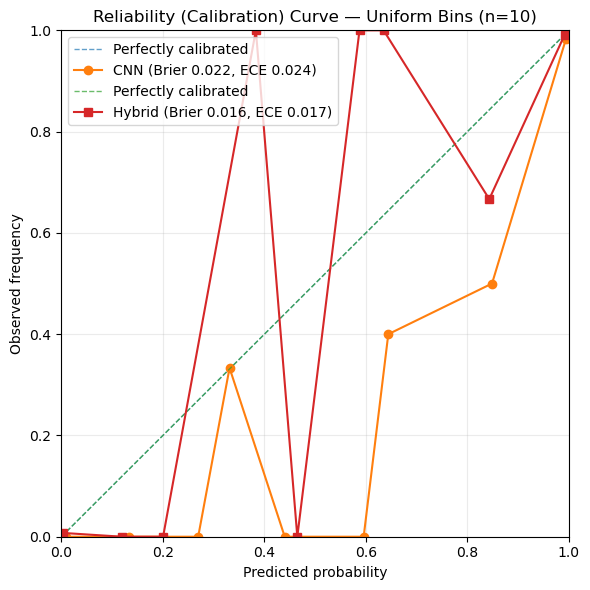

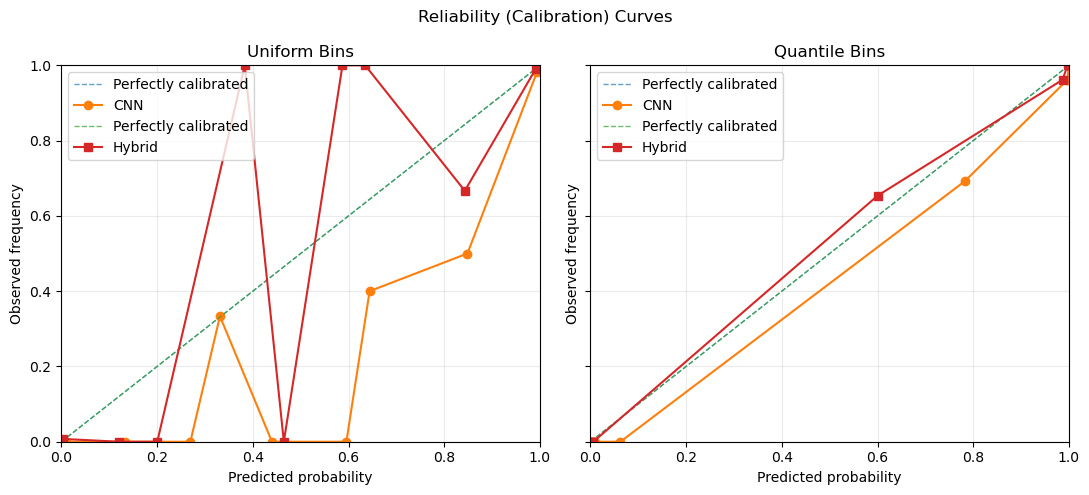

In [29]:
# Reliability Calibration Curves + Brier + ECE for CNN vs Hybrid

import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

y_cnn = res_cnn["targets"].astype(int)
p_cnn = res_cnn["probs"].astype(float)

y_hyb = res_hyb["targets"].astype(int)
p_hyb = res_hyb["probs"].astype(float)

def expected_calibration_error(y_true, y_prob, n_bins=10, strategy="uniform"):
    
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = y_true.shape[0]

    if strategy == "uniform":
        bins = np.linspace(0.0, 1.0, n_bins+1)
        bin_ids = np.digitize(y_prob, bins) - 1 
        bin_ids = np.clip(bin_ids, 0, n_bins-1)
    elif strategy == "quantile":
        
        qs = np.linspace(0, 1, n_bins+1)
        bins = np.unique(np.quantile(y_prob, qs))
        
        if bins.size <= 2:
            bins = np.linspace(0.0, 1.0, n_bins+1)
        bin_ids = np.digitize(y_prob, bins, right=True) - 1
        bin_ids = np.clip(bin_ids, 0, len(bins)-2)
    else:
        raise ValueError("strategy must be 'uniform' or 'quantile'")

    ece = 0.0
    for b in range(n_bins):
        idx = (bin_ids == b)
        n_k = idx.sum()
        if n_k == 0:
            continue
        acc_k = y_true[idx].mean()
        conf_k = y_prob[idx].mean()
        ece += (n_k / N) * abs(acc_k - conf_k)
    return ece

def plot_reliability(ax, y_true, y_prob, label, n_bins=10, strategy="uniform", marker="o"):

    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy=strategy)
    ax.plot([0,1], [0,1], linestyle="--", linewidth=1, alpha=0.7, label="Perfectly calibrated")
    ax.plot(prob_pred, prob_true, marker=marker, linewidth=1.5, label=label)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
    return prob_true, prob_pred

# Compute scores
brier_cnn = brier_score_loss(y_cnn, p_cnn)
brier_hyb = brier_score_loss(y_hyb, p_hyb)
ece_cnn_u = expected_calibration_error(y_cnn, p_cnn, n_bins=10, strategy="uniform")
ece_hyb_u = expected_calibration_error(y_hyb, p_hyb, n_bins=10, strategy="uniform")
ece_cnn_q = expected_calibration_error(y_cnn, p_cnn, n_bins=10, strategy="quantile")
ece_hyb_q = expected_calibration_error(y_hyb, p_hyb, n_bins=10, strategy="quantile")

print(f"CNN    | Brier: {brier_cnn:.4f} | ECE (uniform): {ece_cnn_u:.4f} | ECE (quantile): {ece_cnn_q:.4f}")
print(f"Hybrid | Brier: {brier_hyb:.4f} | ECE (uniform): {ece_hyb_u:.4f} | ECE (quantile): {ece_hyb_q:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
pt_cnn, pp_cnn = plot_reliability(ax, y_cnn, p_cnn, label=f"CNN (Brier {brier_cnn:.3f}, ECE {ece_cnn_u:.3f})",
                                  n_bins=10, strategy="uniform", marker="o")
pt_hyb, pp_hyb = plot_reliability(ax, y_hyb, p_hyb, label=f"Hybrid (Brier {brier_hyb:.3f}, ECE {ece_hyb_u:.3f})",
                                  n_bins=10, strategy="uniform", marker="s")
ax.legend(loc="upper left")
plt.title("Reliability (Calibration) Curve — Uniform Bins (n=10)")
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

plot_reliability(ax1, y_cnn, p_cnn, label="CNN", n_bins=10, strategy="uniform", marker="o")
plot_reliability(ax1, y_hyb, p_hyb, label="Hybrid", n_bins=10, strategy="uniform", marker="s")
ax1.legend(loc="upper left")
ax1.set_title("Uniform Bins")

plot_reliability(ax2, y_cnn, p_cnn, label="CNN", n_bins=10, strategy="quantile", marker="o")
plot_reliability(ax2, y_hyb, p_hyb, label="Hybrid", n_bins=10, strategy="quantile", marker="s")
ax2.legend(loc="upper left")
ax2.set_title("Quantile Bins")

fig.suptitle("Reliability (Calibration) Curves")
plt.tight_layout()
plt.show()


In [2]:
from dataclasses import dataclass
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import transforms

# Config & transform
@dataclass
class CFG:
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    freeze_backbone: bool = False
    img_size: int = 224

cfg = CFG()

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

t_eval = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Simple grid adjacency
def make_grid_adjacency(H: int, W: int, self_loops=True):
    N = H*W
    edges = []
    def node(r, c): return r*W + c
    for r in range(H):
        for c in range(W):
            u = node(r, c)
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                r2, c2 = r+dr, c+dc
                if 0 <= r2 < H and 0 <= c2 < W:
                    v = node(r2, c2)
                    edges.append((u, v))
    A = torch.zeros((N, N), dtype=torch.float32)
    for u, v in edges:
        A[u, v] = 1.0
    if self_loops:
        A += torch.eye(N)
    deg = A.sum(dim=1)
    D_inv_sqrt = torch.diag(torch.pow(deg, -0.5).clamp(min=1e-6))
    A_hat = D_inv_sqrt @ A @ D_inv_sqrt
    return A_hat

# Models
class CNNBaseline(nn.Module):
    def __init__(self, freeze_backbone=False):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.head = nn.Linear(in_feats, 1)

    def forward(self, x):
        feats = self.backbone(x)          
        logit = self.head(feats).squeeze(1)
        return logit

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0, activation=True):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU(inplace=True) if activation else nn.Identity()

    def forward(self, X, A_hat):        
        X = self.lin(X)                   
        X = torch.einsum("ij,bjd->bid", A_hat, X)
        X = self.act(X)
        X = self.dropout(X)
        return X

class CNN_GNN(nn.Module):
    def __init__(self, freeze_backbone=False, g_hidden=256, g_out=128, dropout=0.1):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for p in backbone.parameters(): p.requires_grad = False
        self.stem = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4
        )
        self.feat_dim = 512
        self.pool = nn.AdaptiveAvgPool2d((7,7))
        self.g1 = GCNLayer(self.feat_dim, g_hidden, dropout=dropout, activation=True)
        self.g2 = GCNLayer(g_hidden, g_out, dropout=dropout, activation=True)
        self.head = nn.Linear(g_out, 1)
        H = W = 7
        A_hat = make_grid_adjacency(H, W, self_loops=True)
        self.register_buffer("A_hat", A_hat)

    def forward(self, x):
        fmap = self.stem(x)               
        fmap = self.pool(fmap)           
        B, C, H, W = fmap.shape
        X = fmap.flatten(2).transpose(1, 2)   
        X = self.g1(X, self.A_hat)            
        X = self.g2(X, self.A_hat)            
        X = X.mean(dim=1)                      
        logit = self.head(X).squeeze(1)       
        return logit

# Loader and predict
LABELS = {0: "Non-Infrastructure", 1: "Infrastructure"}

def load_trained_model(model_type="hybrid", ckpt_dir="checkpoints"):
    if model_type.lower() == "hybrid":
        model = CNN_GNN(freeze_backbone=cfg.freeze_backbone).to(cfg.device)
        ckpt_path = f"{ckpt_dir}/hybrid_cnn_gnn_best.pt"
    else:
        model = CNNBaseline(freeze_backbone=cfg.freeze_backbone).to(cfg.device)
        ckpt_path = f"{ckpt_dir}/cnn_baseline_best.pt"
    state = torch.load(ckpt_path, map_location=cfg.device)
    model.load_state_dict(state, strict=True)
    model.eval()
    return model

@torch.no_grad()
def predict_image(image_path, model, threshold=0.5):
    x = t_eval(Image.open(image_path).convert("RGB")).unsqueeze(0).to(cfg.device)
    prob = torch.sigmoid(model(x)).item()
    pred = 1 if prob >= threshold else 0
    return pred, prob

def classify(image_path, model_type="hybrid", threshold=0.5):
    model = load_trained_model(model_type=model_type)
    pred, prob = predict_image(image_path, model, threshold=threshold)
    print(f"[{model_type.upper()}] {image_path} → {LABELS[pred]} | P(infra)={prob:.4f} | thr={threshold}")
    return pred, prob

In [3]:
classify("Highway_700.jpg", "hybrid")

[HYBRID] Highway_700.jpg → Infrastructure | P(infra)=0.9921 | thr=0.5


(1, 0.992093026638031)

In [4]:
classify("Residential_1632.jpg", "hybrid")

[HYBRID] Residential_1632.jpg → Infrastructure | P(infra)=0.9681 | thr=0.5


(1, 0.9680518507957458)

In [5]:
classify("Industrial_412.jpg", "hybrid")

[HYBRID] Industrial_412.jpg → Infrastructure | P(infra)=0.9765 | thr=0.5


(1, 0.9765441417694092)

In [6]:
classify("PermanentCrop_2493.jpg", "hybrid")

[HYBRID] PermanentCrop_2493.jpg → Non-Infrastructure | P(infra)=0.0000 | thr=0.5


(0, 2.7471065550344065e-05)

In [7]:
classify("Forest_944.jpg", "hybrid")

[HYBRID] Forest_944.jpg → Non-Infrastructure | P(infra)=0.0001 | thr=0.5


(0, 0.00013138186477590352)

In [9]:
classify("SeaLake_2861.jpg", "hybrid")

[HYBRID] SeaLake_2861.jpg → Non-Infrastructure | P(infra)=0.0052 | thr=0.5


(0, 0.005240568891167641)

In [10]:
classify("River_411.jpg", "hybrid")

[HYBRID] River_411.jpg → Non-Infrastructure | P(infra)=0.0010 | thr=0.5


(0, 0.0010211203480139375)